In [1]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


TensorFlow: 2.21.0
GPUs available: []


In [2]:
# ── Data paths ───────────────────────────────────────────────────────────────
TRAIN_PKL        = '../data/folds-w-meta.pkl'   # pickle with train folds
TEST_PKL         = '../data/test-w-meta.pkl'     # pickle with test fold
FOLDER_IMAGE_DIR = '../data/classes/'            # optional extra labelled images

# ── Image / training hyper-parameters ────────────────────────────────────────
CLASSIFY_IMAGE_SIZE   = (75, 200)   # native resolution in the pkl files
ESTIMATE_IMAGE_SIZE   = (224, 224)  # EfficientNetB0 expects 224x224
BATCH_SIZE            = 32
CLASSIFIER_EPOCHS     = 10
ESTIMATOR_EPOCHS      = 10

# ── Size-bin definitions ──────────────────────────────────────────────────────
# Upper bound in mm → label string (used as folder names too)

### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']

### Original Bin edges and labels (edges in mm, labels in cm)
#BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
#BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None


In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')  # latin1 handles Python-2-saved pkls

train_folds = load_pkl(TRAIN_PKL)
test_folds  = load_pkl(TEST_PKL)

print(f'Train folds: {len(train_folds)}')
print(f'Keys per fold: {list(train_folds[0].keys())}')
print(f'Images in fold 0: {train_folds[0]["data"].shape}')


Train folds: 10
Keys per fold: ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Images in fold 0: (63, 9, 75, 200, 3)


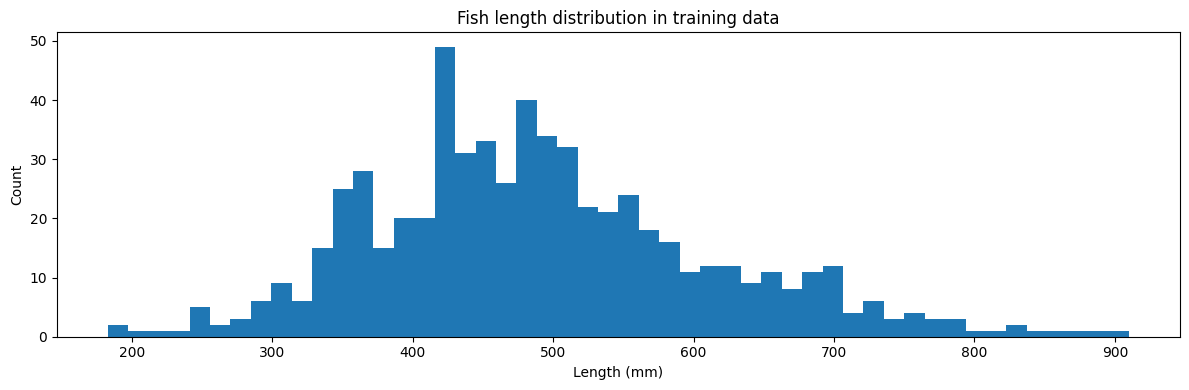

Min: 183mm, Max: 910mm, N: 623


In [4]:
all_lengths = []
for fold in train_folds:
    for length in fold['length']:
        if length is None or str(length).strip() in ('', 'NA'): continue
        all_lengths.append(float(length))

plt.figure(figsize=(12, 4))
plt.hist(all_lengths, bins=50)
plt.xlabel('Length (mm)'); plt.ylabel('Count')
plt.title('Fish length distribution in training data')
plt.tight_layout(); plt.show()

print(f'Min: {min(all_lengths):.0f}mm, Max: {max(all_lengths):.0f}mm, N: {len(all_lengths)}')

# Classification

In [5]:
TRAIN_FOLDS = list(range(0, 8))
VAL_FOLD    = 8
TEST_FOLD   = 9

def load_classification_folds(fold_indices, metadata, label_key='class'):
    """Unpack fold dicts into flat (N*9, 75, 200, 3) image arrays."""
    X_list, y_list = [], []
    for i in fold_indices:
        X = metadata[i]['data']       # (N, 9, 75, 200, 3) — 9 views per fish
        y = metadata[i][label_key]    # (N,)
        X = X.reshape(-1, 75, 200, 3)
        y = np.repeat(y, 9)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_cls_train, y_cls_train = load_classification_folds(TRAIN_FOLDS, train_folds)
X_cls_val,   y_cls_val   = load_classification_folds([VAL_FOLD],  train_folds)
X_cls_test,  y_cls_test  = load_classification_folds([TEST_FOLD], train_folds)

print(f'Train: {X_cls_train.shape}, Val: {X_cls_val.shape}, Test: {X_cls_test.shape}')

# Normalise
X_cls_train = X_cls_train.astype('float32') / 255.0
X_cls_val   = X_cls_val.astype('float32')   / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0

# Encode string species labels → integers
species_le = LabelEncoder()
species_le.fit(np.concatenate([y_cls_train, y_cls_val, y_cls_test]))
y_cls_train_enc = species_le.transform(y_cls_train)
y_cls_val_enc   = species_le.transform(y_cls_val)
y_cls_test_enc  = species_le.transform(y_cls_test)
NUM_SPECIES = len(species_le.classes_)

print(f'Species ({NUM_SPECIES}): {species_le.classes_}')


Train: (4491, 75, 200, 3), Val: (558, 75, 200, 3), Test: (558, 75, 200, 3)
Species (22): ['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']


In [6]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_classifier(num_classes, input_shape=(75, 200, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

classifier = build_classifier(NUM_SPECIES)
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
classifier.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 75, 200,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 75, 200,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 37, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 37, 100,   │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 37, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 37, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 100,   │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 18, 50,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 18, 50,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 18, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 18, 50,    │      2,112 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 18, 50,    │          0 │ batch_normalizat

 Total params: 318,294 (1.21 MB)

 Trainable params: 317,334 (1.21 MB)

 Non-trainable params: 960 (3.75 KB)

## Train Classifier

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.5696 - loss: 1.5812 - val_accuracy: 0.3566 - val_loss: 2.7144
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7684 - loss: 0.8512 - val_accuracy: 0.0968 - val_loss: 3.5200
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8366 - loss: 0.6024 - val_accuracy: 0.1935 - val_loss: 3.2765
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 82ms/step - accuracy: 0.8557 - loss: 0.5035 - val_accuracy: 0.6989 - val_loss: 1.0068
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8835 - loss: 0.4031 - val_accuracy: 0.3387 - val_loss: 5.2893
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.8933 - loss: 0.3720 - val_accuracy: 0.4659 - val_loss: 2.7688
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.9123 - loss: 0.3152 - val_accuracy: 0.2688 - val_loss: 13.5140


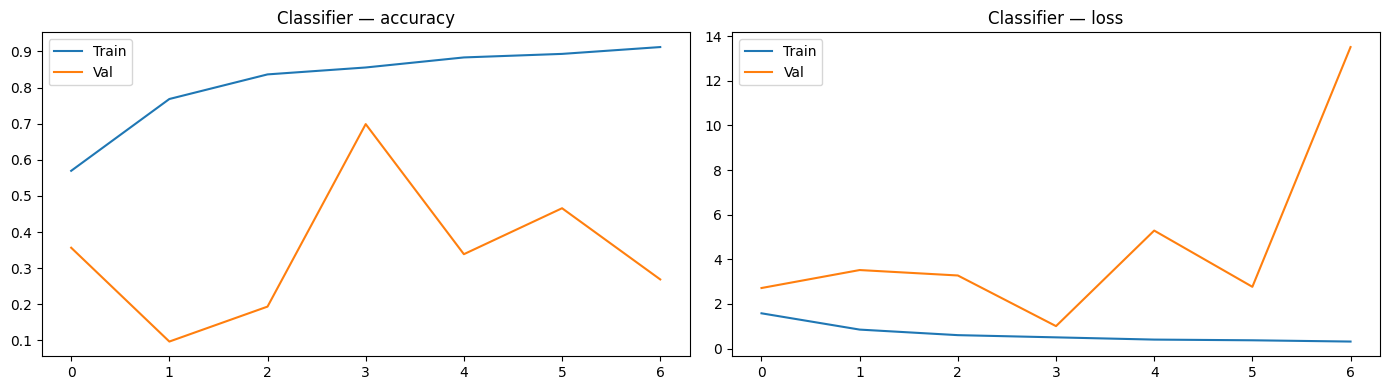

Classifier test accuracy: 53.94%


In [7]:
early_stop_cls = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

cls_history = classifier.fit(
    X_cls_train, y_cls_train_enc,
    validation_data=(X_cls_val, y_cls_val_enc),
    epochs=CLASSIFIER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_cls]
)

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(cls_history.history['accuracy'],     label='Train')
ax1.plot(cls_history.history['val_accuracy'], label='Val')
ax1.set_title('Classifier — accuracy'); ax1.legend()
ax2.plot(cls_history.history['loss'],     label='Train')
ax2.plot(cls_history.history['val_loss'], label='Val')
ax2.set_title('Classifier — loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = classifier.evaluate(X_cls_test, y_cls_test_enc, verbose=0)
print(f'Classifier test accuracy: {test_acc:.2%}')


# Size Estimator

Loading train/val folds...
Loaded 622, skipped 1
Loading test fold...
Loaded 62, skipped 0
Loading folder images...
Folder image directory not found (../data/classes/), skipping.

Train: 497  Val: 125  Test: 62


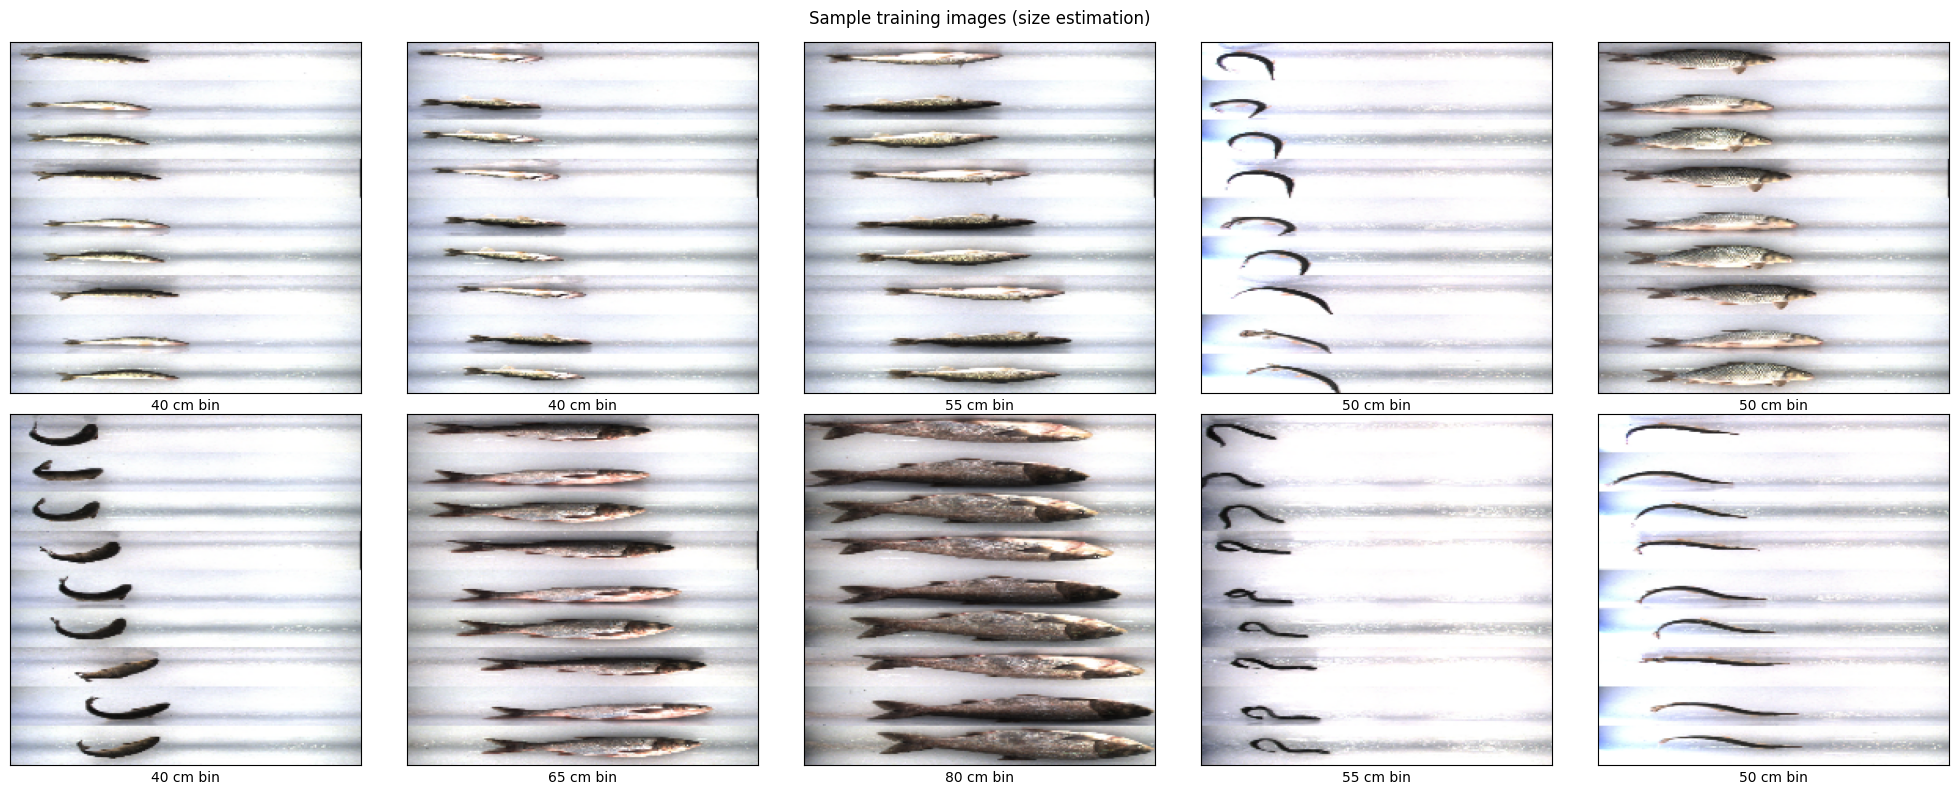

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

def folds_to_arrays_for_estimation(folds):
    """Convert pkl folds to (N, 224, 224, 3) float32 images and size-bin labels."""
    X, y = [], []
    skipped = 0
    for fold in folds:
        for i, raw in enumerate(fold['data']):
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped += 1; continue
            img = np.reshape(raw, (-1, 200, 3)).astype(np.float32)
            img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
            X.append(img_resized)
            y.append(bin_idx)
    print(f'Loaded {len(X)}, skipped {skipped}')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

def load_folder_images(root_dir):
    """Load folder-organised images (root/BIN_LABEL/image.jpg)."""
    if not os.path.isdir(root_dir):
        print(f'Folder image directory not found ({root_dir}), skipping.')
        return np.empty((0, *ESTIMATE_IMAGE_SIZE, 3), dtype=np.float32), np.empty((0,), dtype=np.int32)
    label_to_idx = {label: i for i, label in enumerate(BIN_LABELS)}
    X, y, skipped = [], [], 0
    for folder_name in sorted(os.listdir(root_dir)):
        folder_path = os.path.join(root_dir, folder_name)
        if not os.path.isdir(folder_path): continue
        bin_key = folder_name.lower().replace('class', '').strip()
        if bin_key not in label_to_idx:
            print(f'  Skipping unrecognised folder: {folder_name}'); continue
        bin_idx = label_to_idx[bin_key]
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                raw = tf.io.read_file(fpath)
                img = tf.image.decode_image(raw, channels=3, expand_animations=False)
                img = tf.image.resize(img, ESTIMATE_IMAGE_SIZE)
                X.append(img.numpy().astype(np.float32))
                y.append(bin_idx)
            except Exception as e:
                print(f'  Could not load {fpath}: {e}'); skipped += 1
    print(f'Folder images loaded: {len(X)}, skipped: {skipped}')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Loading train/val folds...')
X_est_pkl, y_est_pkl = folds_to_arrays_for_estimation(train_folds)
print('Loading test fold...')
X_est_test, y_est_test = folds_to_arrays_for_estimation(test_folds)
print('Loading folder images...')
X_folder, y_folder = load_folder_images(FOLDER_IMAGE_DIR)

X_est_all = np.concatenate([X_est_pkl, X_folder], axis=0)
y_est_all = np.concatenate([y_est_pkl, y_folder], axis=0)

X_est_train, X_est_val, y_est_train, y_est_val = train_test_split(
    X_est_all, y_est_all, test_size=0.2, random_state=42, stratify=y_est_all
)
print(f'\nTrain: {X_est_train.shape[0]}  Val: {X_est_val.shape[0]}  Test: {X_est_test.shape[0]}')

est_train_ds = (tf.data.Dataset.from_tensor_slices((X_est_train, y_est_train))
                .shuffle(len(X_est_train), seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE))
est_val_ds   = (tf.data.Dataset.from_tensor_slices((X_est_val, y_est_val))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))
est_test_ds  = (tf.data.Dataset.from_tensor_slices((X_est_test, y_est_test))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# Preview
plt.figure(figsize=(20, 8))
sample_imgs, sample_lbls = next(iter(
    tf.data.Dataset.from_tensor_slices((X_est_train, y_est_train)).batch(10)
))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(sample_imgs[i].numpy().astype('uint8'))
    plt.xlabel(f'{BIN_LABELS[sample_lbls[i]]} cm bin')
plt.suptitle('Sample training images (size estimation)')
plt.tight_layout(); plt.show()


In [9]:
def build_estimator(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
        pooling='avg'
    )
    base.trainable = False  # fine-tune in a later stage if desired
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

estimator = build_estimator(NUM_SIZE_BINS)
estimator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Train Model

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.0946 - loss: 2.7104 - val_accuracy: 0.1840 - val_loss: 2.1889
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.2153 - loss: 2.2296 - val_accuracy: 0.2960 - val_loss: 1.9982
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.2072 - loss: 1.9554 - val_accuracy: 0.3120 - val_loss: 1.9339
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.2475 - loss: 1.8186 - val_accuracy: 0.2640 - val_loss: 1.8871
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.2938 - loss: 1.7207 - val_accuracy: 0.2960 - val_loss: 1.7560
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.3018 - loss: 1.6222 - val_accuracy: 0.3920 - val_loss: 1.7463
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - accuracy: 0.3219 - loss: 1.5584 - val_accuracy: 0.3680 - val_loss: 1.7055
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.3843 - loss: 1.5488 - val_accuracy: 0.

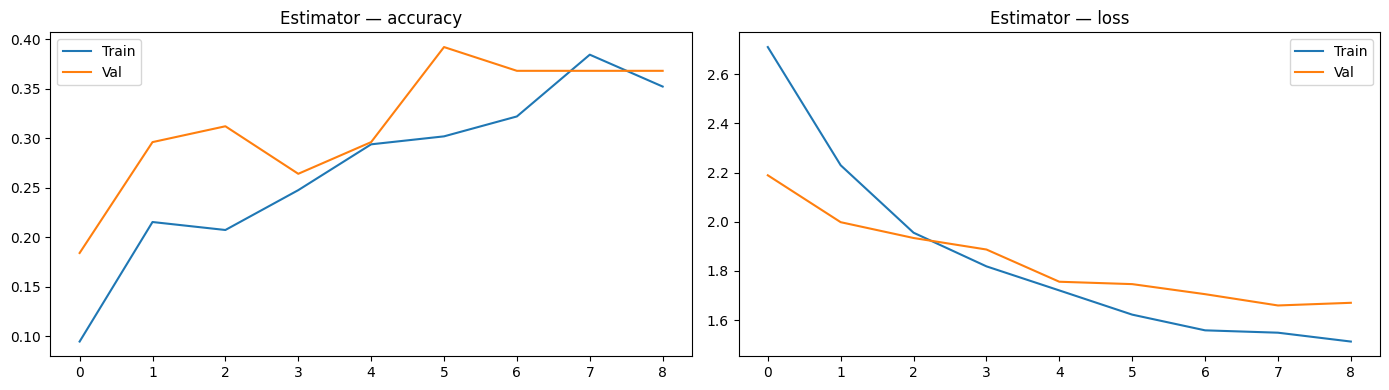

Train  — loss: 1.7261, accuracy: 38.83%
Val    — loss: 1.7463, accuracy: 39.20%
Test   — loss: 1.6655, accuracy: 46.77%


In [10]:
unique_bins = np.unique(y_est_train)
est_weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_est_train)
est_class_weights = dict(zip(unique_bins, est_weights_arr))

early_stop_est = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

est_history = estimator.fit(
    est_train_ds,
    validation_data=est_val_ds,
    epochs=ESTIMATOR_EPOCHS,
    class_weight=est_class_weights,
    callbacks=[early_stop_est]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(est_history.history['accuracy'],     label='Train')
ax1.plot(est_history.history['val_accuracy'], label='Val')
ax1.set_title('Estimator — accuracy'); ax1.legend()
ax2.plot(est_history.history['loss'],     label='Train')
ax2.plot(est_history.history['val_loss'], label='Val')
ax2.set_title('Estimator — loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(est_train_ds, 'Train'), (est_val_ds, 'Val'), (est_test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')


## Combined Inference

Blends the estimator's softmax output with the classifier's species-informed size distribution. **`alpha`** is the weight on the **estimator**; `(1 - alpha)` is the weight on the species-informed prior (`SPECIES_SIZE_PRIOR` from `configs/species_priors_by_code.yaml`).

- **Baselines:** `α=1.0` (estimator only), `α=0.0` (prior only)
- **Sweep:** test many `α` values on the aligned test set and pick the best for the confusion matrix

In [11]:
# ── Biological priors: P(size bin | species) ───────────────────────────────────
from pathlib import Path

PRIORS_BY_CODE_PATH = Path('../configs/species_priors_by_code.yaml')


def load_species_priors_by_code(path):
    """Load mean/min/max priors from simple YAML (no PyYAML dependency)."""
    priors = {}
    species = None
    for raw in Path(path).read_text().splitlines():
        line = raw.split('#', 1)[0].strip()
        if not line:
            continue
        if line.endswith(':') and ' ' not in line.rstrip(':'):
            species = line[:-1].strip()
            priors[species] = {}
            continue
        if species is None:
            continue
        key, _, val = line.partition(':')
        if val.strip():
            priors[species][key.strip()] = float(val.strip())
    return priors


def build_prior_matrix(species_classes, bin_labels, priors_by_code, sigma_scale=0.25):
    """Truncated Gaussian over bin centers; uniform row if species stats missing."""
    bin_centers = np.array([float(label) for label in bin_labels], dtype=np.float32)
    num_species = len(species_classes)
    num_bins = len(bin_labels)
    matrix = np.zeros((num_species, num_bins), dtype=np.float32)
    uniform = np.full(num_bins, 1.0 / num_bins, dtype=np.float32)

    for i, code in enumerate(species_classes):
        stats = priors_by_code.get(code)
        if not stats:
            matrix[i] = uniform
            continue
        mu = stats['mean_length_cm']
        lo = stats['min_length_cm']
        hi = stats['max_length_cm']
        sigma = max((hi - lo) * sigma_scale, 1.0)
        w = np.exp(-0.5 * ((bin_centers - mu) / sigma) ** 2)
        w *= (bin_centers >= lo) & (bin_centers <= hi)
        matrix[i] = w / w.sum() if w.sum() > 0 else uniform

    return matrix


priors_by_code = load_species_priors_by_code(PRIORS_BY_CODE_PATH)
SPECIES_SIZE_PRIOR = build_prior_matrix(species_le.classes_, BIN_LABELS, priors_by_code)

assert SPECIES_SIZE_PRIOR.shape == (NUM_SPECIES, NUM_SIZE_BINS)
assert np.allclose(SPECIES_SIZE_PRIOR.sum(axis=1), 1.0)

mapped = sum(1 for c in species_le.classes_ if c in priors_by_code)
print(
    f'Biological priors: {mapped}/{NUM_SPECIES} species with stats, '
    f'{NUM_SPECIES - mapped} uniform fallback rows'
)


Biological priors: 22/22 species with stats, 0 uniform fallback rows


In [12]:
def predict_combined(images_224, images_75_200, alpha=0.5):
    """
    Predict size bins by blending the size estimator and species classifier outputs.

    Parameters
    ----------
    images_224    : (N, 224, 224, 3) float32 — input for the size estimator
    images_75_200 : (N,  75, 200, 3) float32 — input for the species classifier
    alpha         : float in [0, 1] — weight on the estimator (1 = estimator only, 0 = prior only)

    Returns
    -------
    pred_bins : (N,) int array of predicted size-bin indices
    """
    # Size estimator: P(bin | image)
    est_probs = estimator.predict(images_224, verbose=0)          # (N, NUM_SIZE_BINS)

    # Classifier: P(species | image)
    species_probs = classifier.predict(images_75_200, verbose=0)  # (N, NUM_SPECIES)

    # Species-informed size prior: P(bin) = sum_s P(species=s|image) * P(bin|species=s)
    prior_scores = species_probs @ SPECIES_SIZE_PRIOR              # (N, NUM_SIZE_BINS)

    combined  = alpha * est_probs + (1 - alpha) * prior_scores
    pred_bins = np.argmax(combined, axis=1)
    return pred_bins


# ── Build the 75x200 test set (needed by the classifier) ─────────────────────
# Note: reshape to (75, 200, 3) explicitly — (-1, 200, 3) would incorrectly
# collapse all rows across the batch into a single dimension.
X_test_75_list = []
X_est_test_list = []
y_est_test_list = []

for fold in test_folds:
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue

        # One 75x200 view (view 0) per fish for the classifier
        img_75 = np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32) / 255.0
        X_test_75_list.append(img_75)

        # One 224x224 image per fish for the estimator
        img_224 = tf.image.resize(
            np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32),
            ESTIMATE_IMAGE_SIZE
        ).numpy() / 255.0
        X_est_test_list.append(img_224)

        y_est_test_list.append(bin_idx)

X_test_75       = np.array(X_test_75_list,  dtype=np.float32)
X_est_test_norm = np.array(X_est_test_list, dtype=np.float32)
y_est_test_aligned = np.array(y_est_test_list, dtype=np.int32)
print(f'Aligned test set: {len(y_est_test_aligned)} fish')


Aligned test set: 62 fish


Alpha baselines (aligned test set):
  Estimator only (α=1.0)       0.00%
  Prior only (α=0.0)           25.81%
  Equal blend (α=0.5)          6.45%

Best α = 0.00  →  accuracy 25.81%


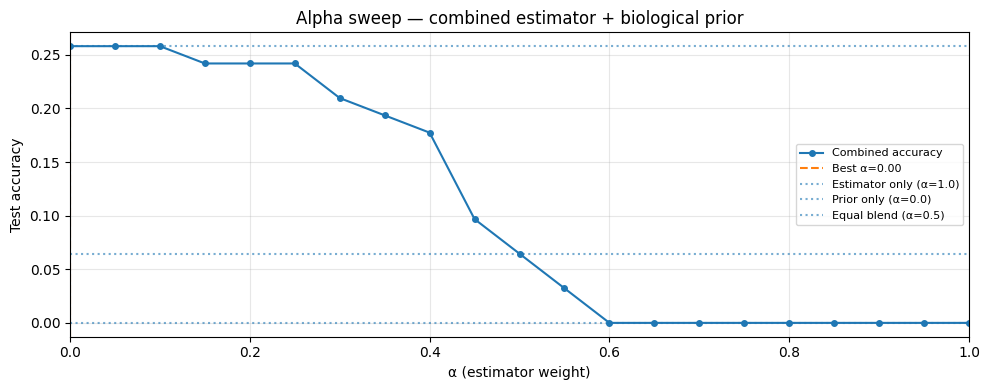

In [13]:
# ── Alpha baselines & sweep (single predict pass, then blend) ─────────────────
y_true = y_est_test_aligned

est_probs     = estimator.predict(X_est_test_norm, verbose=0)       # (N, NUM_SIZE_BINS)
species_probs = classifier.predict(X_test_75, verbose=0)            # (N, NUM_SPECIES)
prior_scores  = species_probs @ SPECIES_SIZE_PRIOR                    # (N, NUM_SIZE_BINS)


def blend_and_predict(alpha):
    combined = alpha * est_probs + (1.0 - alpha) * prior_scores
    return np.argmax(combined, axis=1)


def bin_accuracy(preds):
    return np.mean(preds == y_true)


# ── Baselines ─────────────────────────────────────────────────────────────────
ALPHA_BASELINES = [
    (1.0, 'Estimator only (α=1.0)'),
    (0.0, 'Prior only (α=0.0)'),
    (0.5, 'Equal blend (α=0.5)'),
]

print('Alpha baselines (aligned test set):')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    print(f'  {label:<28} {acc:.2%}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
sweep_acc = [bin_accuracy(blend_and_predict(a)) for a in ALPHAS]

best_idx   = int(np.argmax(sweep_acc))
BEST_ALPHA = float(ALPHAS[best_idx])
best_acc   = sweep_acc[best_idx]

print(f'\nBest α = {BEST_ALPHA:.2f}  →  accuracy {best_acc:.2%}')

# ── Plot sweep ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ALPHAS, sweep_acc, marker='o', markersize=4, label='Combined accuracy')
ax.axvline(BEST_ALPHA, color='C1', ls='--', label=f'Best α={BEST_ALPHA:.2f}')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    ax.axhline(acc, ls=':', alpha=0.6, label=label)
ax.set_xlabel('α (estimator weight)')
ax.set_ylabel('Test accuracy')
ax.set_title('Alpha sweep — combined estimator + biological prior')
ax.set_xlim(0, 1)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predictions at best α for confusion matrix below
pred_bins = blend_and_predict(BEST_ALPHA)


### Confusion matrix — combined pipeline (best α from sweep)

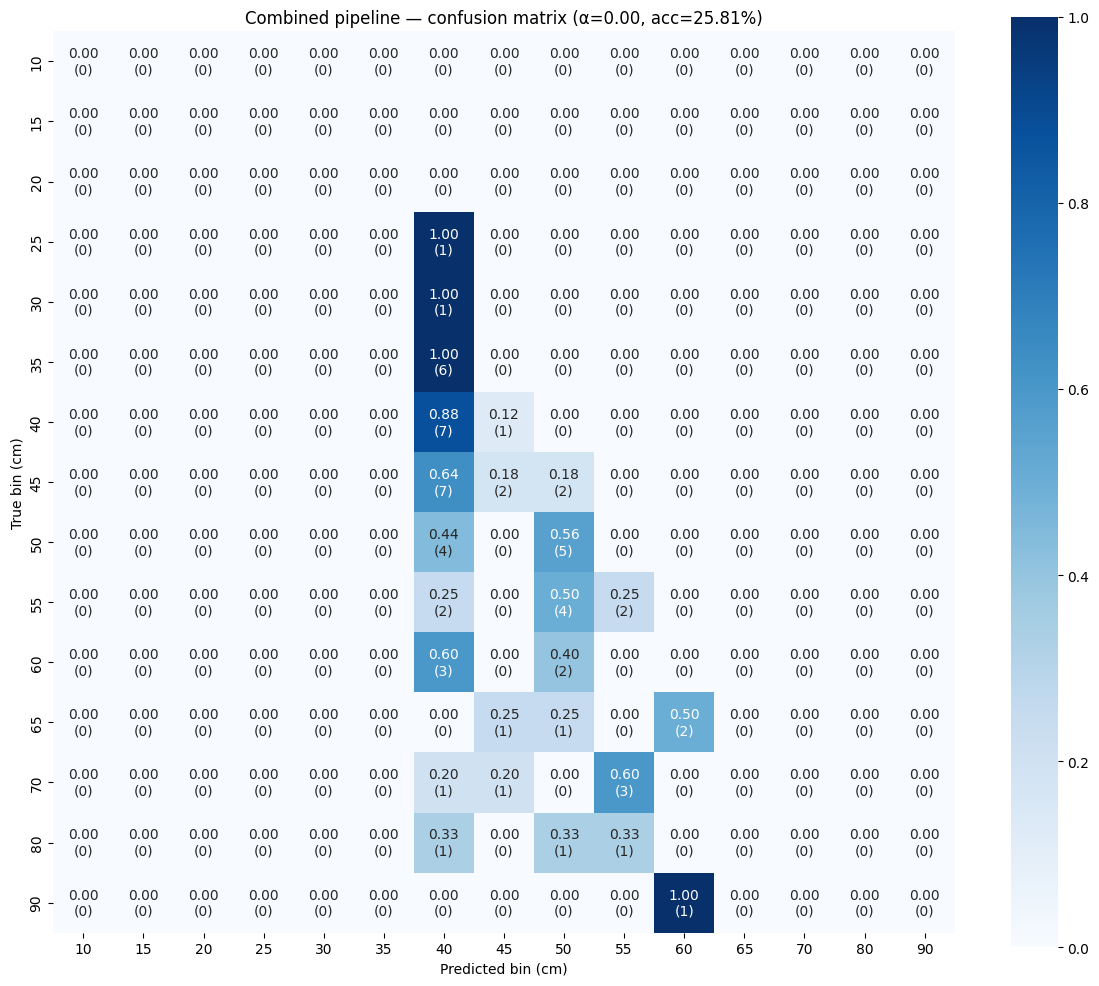

In [14]:
cm      = confusion_matrix(y_est_test_aligned, pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'Combined pipeline — confusion matrix (α={BEST_ALPHA:.2f}, acc={best_acc:.2%})')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()
